# Intelligent Student Performance Prediction System (P-8)
## Decision Tree experimentation
This notebook uses exactly the same data, four-class target, and Decision Tree method as `app.py`. The four classes are project-defined proxy categories, not labels supplied by the source dataset.

In [1]:
from pathlib import Path
import sys, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
from src.preprocessing import FEATURES, load_data, add_performance_target
from src.evaluate import evaluate_model

## Load, clean, and inspect
The loader renames `Midterm_Marks` to `Internal_Marks`, validates numeric ranges, removes duplicate rows, and rejects missing required values.

In [2]:
data_path = Path('data/Student_Performance.csv') if Path('data').exists() else Path('../data/Student_Performance.csv')
raw = load_data(data_path)
print('Shape:', raw.shape)
print('Missing:', raw.isna().sum().to_dict())
print('Duplicates:', raw.duplicated().sum())
raw.describe()

Shape: (200, 6)
Missing: {'Attendance_Percentage': 0, 'Internal_Marks': 0, 'Assignment_Score': 0, 'Study_Hours_Per_Week': 0, 'Previous_GPA': 0, 'Final_Result': 0}
Duplicates: 0


,Attendance_Percentage,Internal_Marks,Assignment_Score,Study_Hours_Per_Week,Previous_GPA
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,70.235000,50.295000,48.670000,20.990000,2.945000
std,18.045999,29.719086,29.738409,10.653044,0.604926
min,40.000000,0.000000,0.000000,1.000000,2.010000
25%,54.750000,24.000000,24.000000,12.000000,2.437500
50%,72.000000,49.000000,47.500000,21.000000,2.905000
75%,86.000000,77.000000,74.250000,30.000000,3.425000
max,99.000000,99.000000,99.000000,39.000000,4.000000


## Prepare four-class target
The documented index bands are Poor <45, Average 45–<60, Good 60–<75, and Excellent ≥75. `Final_Result` is never in `FEATURES`, so it is not leaked to the classifier.

Performance_Class
Excellent    29
Good         64
Average      49
Poor         58
Name: count, dtype: int64


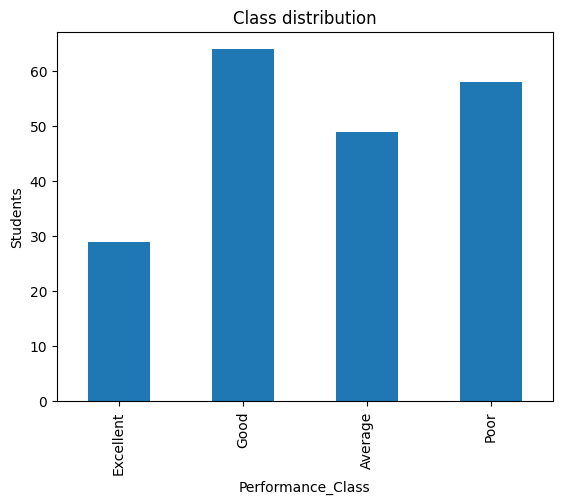

In [3]:
data = add_performance_target(raw)
distribution = data.Performance_Class.value_counts().reindex(['Excellent','Good','Average','Poor'])
print(distribution)
distribution.plot.bar(title='Class distribution', ylabel='Students');

## Train/test split and overfitting comparison
The held-out test set is not used for fitting. The basic tree is compared with the persisted depth-limited tree.

In [4]:
X, y = data[FEATURES], data.Performance_Class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)
basic = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, class_weight='balanced', random_state=42).fit(X_train, y_train)
print('Basic train/test:', basic.score(X_train,y_train), basic.score(X_test,y_test))
print('Limited train/test:', model.score(X_train,y_train), model.score(X_test,y_test))

Basic train/test: 1.0 0.58
Limited train/test: 0.8466666666666667 0.56


## Held-out multiclass evaluation
Weighted precision, recall, and F1 are appropriate because the classes are not equally represented.

              precision    recall  f1-score   support

        Poor       0.61      0.73      0.67        15
     Average       0.44      0.33      0.38        12
        Good       0.64      0.44      0.52        16
   Excellent       0.50      0.86      0.63         7

    accuracy                           0.56        50
   macro avg       0.55      0.59      0.55        50
weighted avg       0.56      0.56      0.55        50



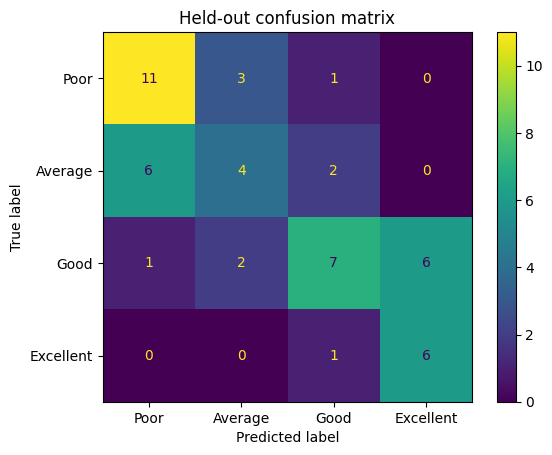

In [5]:
metrics = evaluate_model(model, X_test, y_test)
{k: round(v,4) for k,v in metrics.items() if isinstance(v,float)}
print(metrics['classification_report'])
ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test), labels=metrics['class_order']);
plt.title('Held-out confusion matrix');

## Feature importance and tree
These figures are generated from the fitted model, never hard-coded.

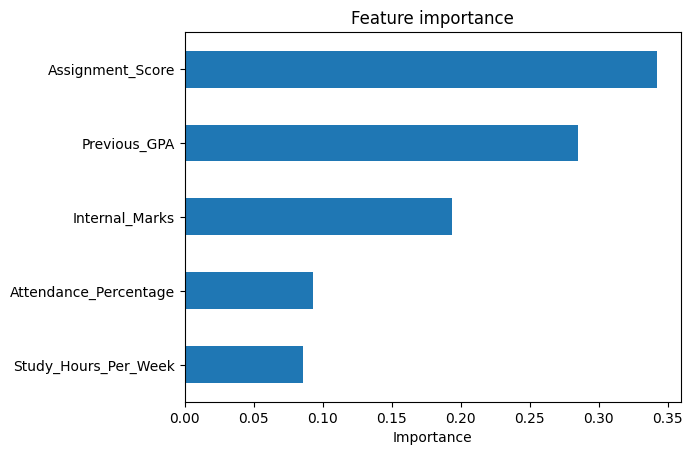

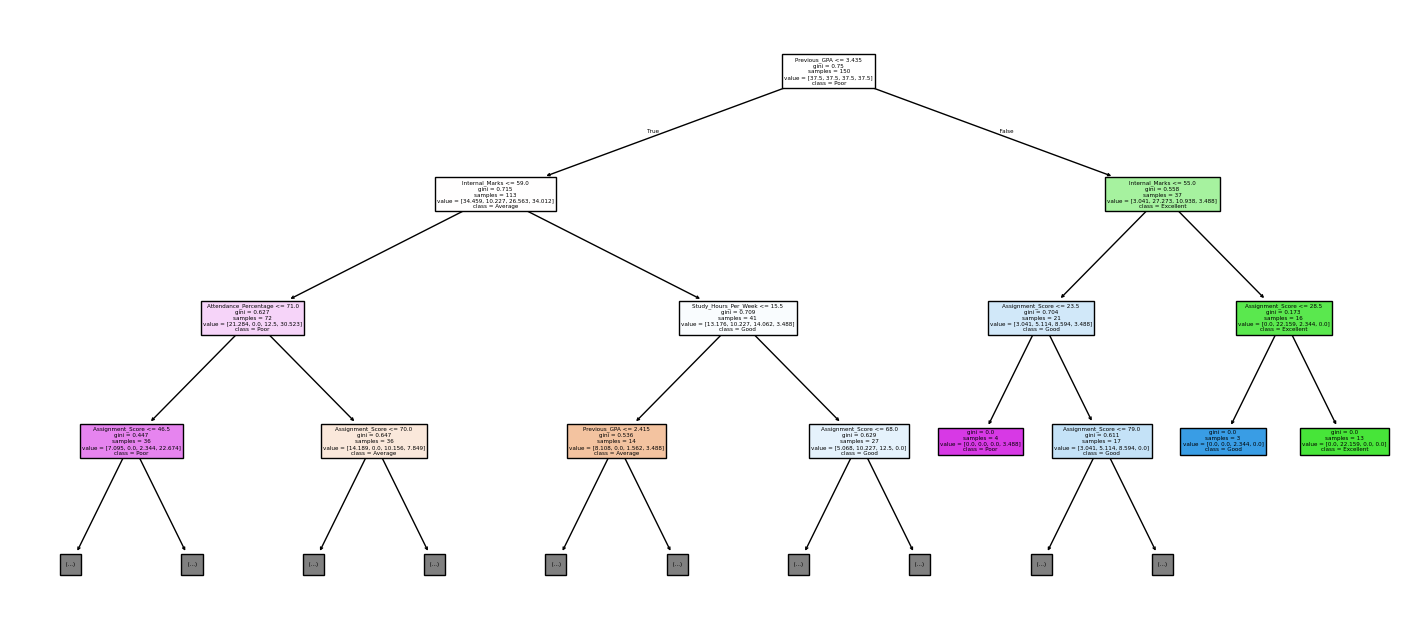

In [6]:
pd.Series(metrics['feature_importance']).sort_values().plot.barh(title='Feature importance');
plt.xlabel('Importance');
plt.figure(figsize=(18,8))
plot_tree(model, feature_names=FEATURES, class_names=model.classes_, filled=True, max_depth=3);

## Conclusion
The saved limited Decision Tree powers the dashboard. Because the dataset is small and uses proxy labels, it should be treated as a project demonstration rather than a high-stakes decision system.